In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('diabetic_data.csv')

print("Shape of the dataset:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())
print("\nInformation about the dataset:")
print(df.info())

# Check for the custom missing value indicator '?' in all columns
print("\nColumns containing '?' missing values:")
for col in df.columns:
    if (df[col] == '?').any():
        print(f"- {col}")

Shape of the dataset: (101766, 50)

First 5 rows of the dataset:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \


In [7]:
# Replace '?' with NaN for proper missing value handling
df.replace('?', np.nan, inplace=True)

# Re-evaluate missing values (including '?' replaced with NaN)
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Columns with missing values (and their percentages):")
print(missing_df)

Columns with missing values (and their percentages):
                   Missing Count  Missing Percentage
weight                     98569           96.858479
max_glu_serum              96420           94.746772
A1Cresult                  84748           83.277322
medical_specialty          49949           49.082208
payer_code                 40256           39.557416
race                        2273            2.233555
diag_3                      1423            1.398306
diag_2                       358            0.351787
diag_1                        21            0.020636



Value Counts for 'readmitted' (Original Target):
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Value Counts for 'is_readmitted' (Binary Target):
is_readmitted
0    54864
1    46902
Name: count, dtype: int64


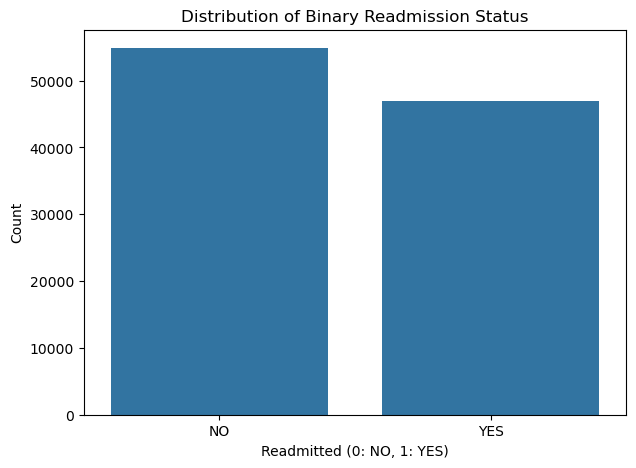

In [8]:
# Create a binary target variable 'is_readmitted'
# 1 = Readmitted (<30 or >30), 0 = Not Readmitted (NO)
df['is_readmitted'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)

print("\nValue Counts for 'readmitted' (Original Target):")
print(df['readmitted'].value_counts())
print("\nValue Counts for 'is_readmitted' (Binary Target):")
print(df['is_readmitted'].value_counts())

# Plot the distribution of the binary target variable
plt.figure(figsize=(7, 5))
sns.countplot(x='is_readmitted', data=df)
plt.title('Distribution of Binary Readmission Status')
plt.xlabel('Readmitted (0: NO, 1: YES)')
plt.ylabel('Count')
plt.xticks([0, 1], ['NO', 'YES'])
plt.show() # In a Jupyter Notebook, show() would display the saved image

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8992\999423838.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='age', data=df, order=df['age'].value_counts().index, palette='viridis')


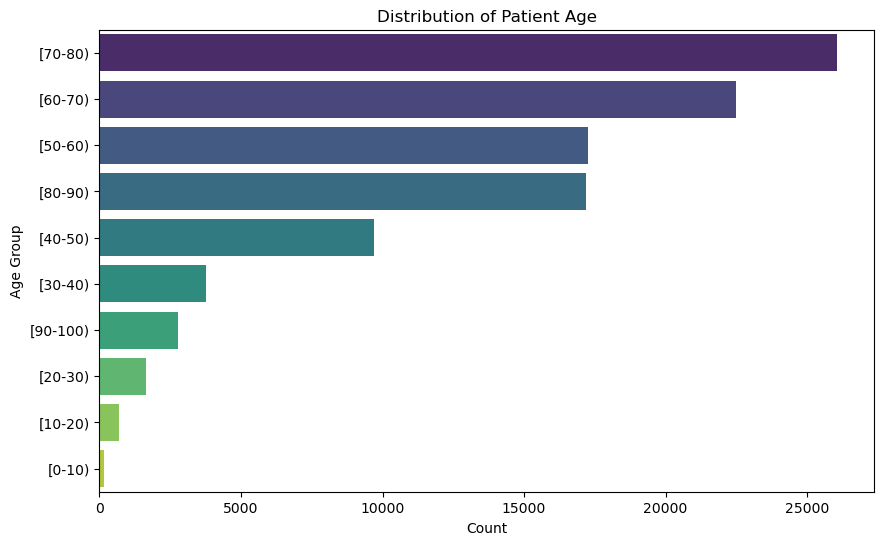

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8992\999423838.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='race', data=df.dropna(subset=['race']), order=df['race'].value_counts().index, palette='magma')


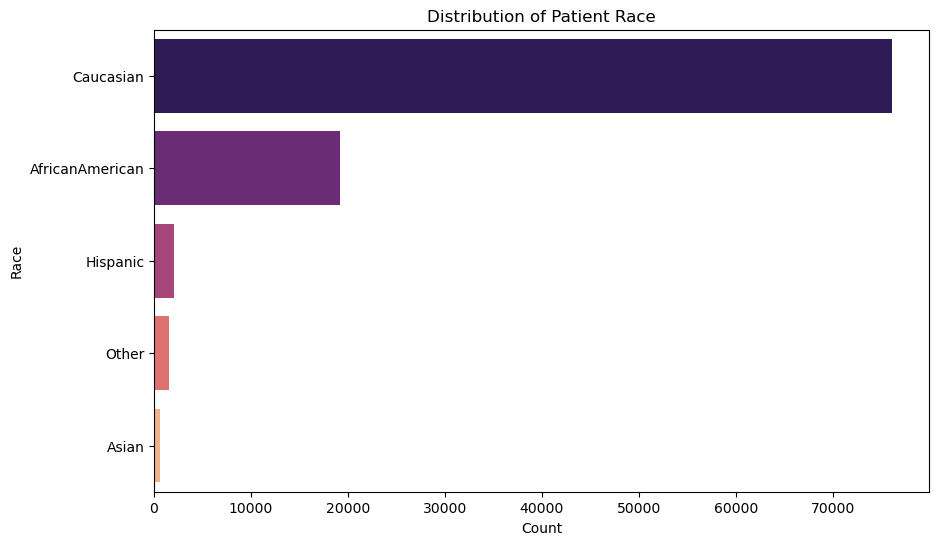

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8992\999423838.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='cividis')


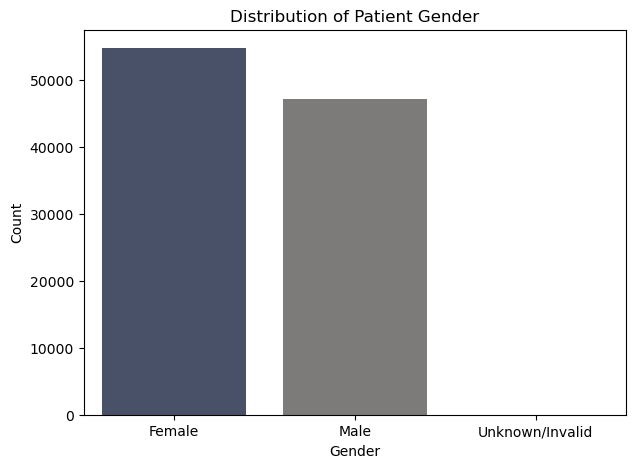


Value Counts for 'gender':
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [9]:
# 1. Age Distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='age', data=df, order=df['age'].value_counts().index, palette='viridis')
plt.title('Distribution of Patient Age')
plt.xlabel('Count')
plt.ylabel('Age Group')
plt.show()

# 2. Race Distribution (dropping NaN for visualization)
plt.figure(figsize=(10, 6))
sns.countplot(y='race', data=df.dropna(subset=['race']), order=df['race'].value_counts().index, palette='magma')
plt.title('Distribution of Patient Race')
plt.xlabel('Count')
plt.ylabel('Race')
plt.show()

# 3. Gender Distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='gender', data=df, palette='cividis')
plt.title('Distribution of Patient Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

print("\nValue Counts for 'gender':")
print(df['gender'].value_counts())

In [10]:
# 1. Feature Elimination
# Drop 'weight', 'payer_code', and 'medical_specialty' due to high missing percentages.
# Drop identifiers 'encounter_id' and 'patient_nbr' as they are unique to each record.
cols_to_drop = ['weight', 'payer_code', 'medical_specialty', 'encounter_id', 'patient_nbr', 'readmitted']
df_model = df.drop(columns=cols_to_drop)

# 2. Handle Minor Missing/Invalid Values
# Drop 3 rows with 'Unknown/Invalid' gender
df_model = df_model[df_model['gender'] != 'Unknown/Invalid']

# Drop rows with NaN in 'race' and the diagnostic codes (less than 3% missing total)
df_model.dropna(inplace=True)

# 3. Handle Other Low-Variance/Redundant Columns
# 'examide' and 'citoglipton' have only one unique value (No) - they should be dropped
cols_to_drop_low_variance = ['examide', 'citoglipton']
df_model = df_model.drop(columns=cols_to_drop_low_variance)

# 4. Feature Encoding (One-Hot Encoding for most categorical features)
# Select all remaining 'object' type columns for encoding (except the binary target 'is_readmitted')
categorical_cols = df_model.select_dtypes(include=['object']).columns

# Apply One-Hot Encoding
df_model_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("\nShape of the dataset after cleaning and encoding:")
print(df_model_encoded.shape)
print("\nFirst 5 rows of the prepared dataset (after encoding):")
print(df_model_encoded.head())

# The resulting df_model_encoded is ready for a classification model (e.g., Logistic Regression, Random Forest).


Shape of the dataset after cleaning and encoding:
(289, 347)

First 5 rows of the prepared dataset (after encoding):
     admission_type_id  discharge_disposition_id  admission_source_id  \
162                  6                         3                    7   
460                  6                         1                    7   
593                  6                         1                    7   
696                  6                         6                    7   
771                  6                         1                    2   

     time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
162                 5                  47               1                6   
460                10                  72               1               19   
593                 2                  61               0                5   
696                11                  71               1               20   
771                14                  43            